In [1]:
import json
from cs336_alignment.drgrpo_grader import r1_zero_reward_fn, grade_answer_mathd, grade_answer_sympy, grade, r1_zero_reward_fn_gsm8k
from cs336_alignment.eval import extract_reference_answer, load_and_format_prompts

PROMPT_PATH = "/root/autodl-tmp/assignment5-alignment/cs336_alignment/prompts/r1_zero.prompt"
MATH_DATA_PATH = "/root/autodl-tmp/assignment5-alignment/data/gsm8k"

ZERO_SHOT_RES_PATH = "/root/autodl-tmp/assignment5-alignment/results/zero-shot_result.jsonl"
TRAIN_SFT_RES_PATH = "/root/autodl-tmp/assignment5-alignment/results/train_sft_7473_results.jsonl"

## data

### gsm8k

In [2]:
train_prompts, train_answers = load_and_format_prompts(MATH_DATA_PATH + "/train.jsonl", PROMPT_PATH)
test_prompts, test_answers = load_and_format_prompts(MATH_DATA_PATH + "/test.jsonl", PROMPT_PATH)

In [3]:
train_answers[0], test_answers[0]

('Natalia sold 48/2 = <<48/2=24>>24 clips in May.\nNatalia sold 48+24 = <<48+24=72>>72 clips altogether in April and May.\n#### 72',
 'Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.\nShe makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.\n#### 18')

In [6]:
import numpy as np

train_answers_length = [len(ans) for ans in train_answers]

rollout_batch_size = 64
group_size = 8
n_prompts_per_rollout_batch = rollout_batch_size // group_size
n_grpo_steps = 48
n_train_samples = n_grpo_steps * n_prompts_per_rollout_batch

averages = []
for i in range(0, len(train_answers_length[:n_train_samples]), n_prompts_per_rollout_batch):
    group = train_answers_length[i:i+n_prompts_per_rollout_batch]
    averages.append(np.mean(group))


y = averages
x = list(range(len(y)))

/root/autodl-tmp/assignment5-alignment/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24207 (\N{CJK UNIFIED IDEOGRAPH-5E8F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/autodl-tmp/assignment5-alignment/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


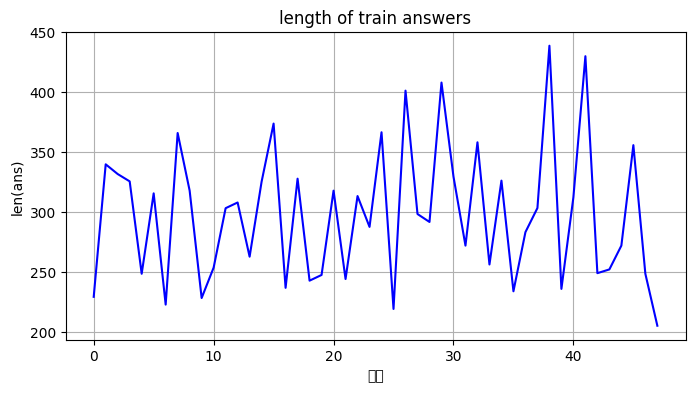

In [7]:
import matplotlib.pyplot as plt

# 绘图
plt.figure(figsize=(8, 4))
plt.plot(x, y, linestyle='-', color='b')

# 添加标签和标题
plt.xlabel("序号")
plt.ylabel("len(ans)")
plt.title("length of train answers")
plt.grid(True)

# 显示
plt.show()

### math12k

In [8]:
from datasets import load_dataset

MATH12K_DATA_PATH = "/root/autodl-tmp/assignment5-alignment/data/math12k"
test_dataset  = load_dataset(MATH12K_DATA_PATH, split="test")
print(test_dataset)

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id'],
    num_rows: 500
})


In [ ]:
test_dataset[0]

{'problem': 'Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\\theta),$ where $r > 0$ and $0 \\le \\theta < 2 \\pi.$',
 'solution': 'We have that $r = \\sqrt{0^2 + 3^2} = 3.$  Also, if we draw the line connecting the origin and $(0,3),$ this line makes an angle of $\\frac{\\pi}{2}$ with the positive $x$-axis.\n\n[asy]\nunitsize(0.8 cm);\n\ndraw((-0.5,0)--(3.5,0));\ndraw((0,-0.5)--(0,3.5));\ndraw(arc((0,0),3,0,90),red,Arrow(6));\n\ndot((0,3), red);\nlabel("$(0,3)$", (0,3), W);\ndot((3,0), red);\n[/asy]\n\nTherefore, the polar coordinates are $\\boxed{\\left( 3, \\frac{\\pi}{2} \\right)}.$',
 'answer': '\\left( 3, \\frac{\\pi}{2} \\right)',
 'subject': 'Precalculus',
 'level': 2,
 'unique_id': 'test/precalculus/807.json'}

## zero-shot

In [15]:
# test r1_zero_reward_fn_gsm8k
r1_zero_reward_fn = r1_zero_reward_fn_gsm8k
cases = [
    ("</think> <answer>18</answer>", "18"),
    ("</think> <answer>18 dollars</answer>", "18"),
    ("</think> <answer>$18</answer>", "18"),
    ("</think> <answer>The answer is 18.</answer>", "18"),
    ("</think> <answer>18 apples</answer>", "18"),
    ("</think> <answer>18.0</answer>", "18"),
]

for resp, gt in cases:
    print(resp, r1_zero_reward_fn(resp, gt))

</think> <answer>18</answer> {'format_reward': 1.0, 'answer_reward': 1.0, 'reward': 1.0}
</think> <answer>18 dollars</answer> {'format_reward': 1.0, 'answer_reward': 1.0, 'reward': 1.0}
</think> <answer>$18</answer> {'format_reward': 1.0, 'answer_reward': 1.0, 'reward': 1.0}
</think> <answer>The answer is 18.</answer> {'format_reward': 1.0, 'answer_reward': 0.0, 'reward': 0.0}
</think> <answer>18 apples</answer> {'format_reward': 1.0, 'answer_reward': 1.0, 'reward': 1.0}
</think> <answer>18.0</answer> {'format_reward': 1.0, 'answer_reward': 1.0, 'reward': 1.0}


In [2]:
r1_zero_reward_fn = r1_zero_reward_fn_gsm8k

with open(ZERO_SHOT_RES_PATH, "r") as f:
    zero_shot_results = [json.loads(line) for line in f]

sample = zero_shot_results[0]
response = sample["response"]
answer = sample["extracted_answer"]
reward = r1_zero_reward_fn(response, answer)

print("Response:", response)
print("Answer:", answer)
print("Reward:", reward)

Response: We need to calculate the number of eggs Janet sells daily. First, we subtract the eggs she eats from the total eggs laid. Janet's ducks lay 16 eggs per day, she eats 3 for breakfast every morning, and she bakes muffins for her friends every day with 4 eggs. Thus, the number of eggs she sells each day is \(16 - 3 - 4 = 9\). Each sold egg is sold for $2. Therefore, the daily revenue from selling eggs is \(9 \times 2 = 18\) dollars. </think> <answer> 18 dollars </answer>
Answer: 18
Reward: {'format_reward': 1.0, 'answer_reward': 1.0, 'reward': 1.0}


In [9]:
model_answer = response.split("<answer>")[-1].replace("</answer>", "")
model_answer

' 18 dollars '

In [29]:
grade(' 18 dollars ', '18', fast=True)

False

## sft

In [22]:
with open(TRAIN_SFT_RES_PATH, "r") as f:
    train_sft_results = [json.loads(line) for line in f]

wrong_samples = [res for res in train_sft_results if res["reward"] < 0.5]
correct_samples = [res for res in train_sft_results if res["reward"] >= 0.5]
print(len(wrong_samples), len(correct_samples))

sample = correct_samples[20]
sample['prompt'][420:], sample['response'], sample['answer']

358 961


("Darrell and Allen's ages are in the ratio of 7:11. If their total age now is 162, calculate Allen's age 10 years from now.\nAssistant: <think>",
 "Let x be the common ratio\n7x + 11x = 162\n18x = 162\nx = 162/18\nx = <<9=9>>9\nAllen's age = 11x = 11*9 = <<11*9=99>>99\nAllen's age 10 years from now = 99 + 10 = <<99+10=109>>109</think> <answer> 109 </answer>",
 "The total ratio representing their ages is 7+11= <<7+11=18>>18\nSince the fraction of the ratio that represents Allen's age is 11/18, Allen's current age is 11/18*162 = <<11/18*162=99>>99\nIf Allen is currently 99 years old, in 10 years he will be 99+10 = <<99+10=109>>109 years old\n#### 109")

In [25]:
wrong_answer_avglen = sum(len(res["answer"]) for res in wrong_samples) / len(wrong_samples)
correct_answer_avglen = sum(len(res["answer"]) for res in correct_samples) / len(correct_samples)
print("Wrong answer average length:", wrong_answer_avglen)
print("Correct answer average length:", correct_answer_avglen)

wrong_response_avglen = sum(len(res["response"]) for res in wrong_samples) / len(wrong_samples)
correct_response_avglen = sum(len(res["response"]) for res in correct_samples) / len(correct_samples)
print("Wrong response average length:", wrong_response_avglen)
print("Correct response average length:", correct_response_avglen)

Wrong answer average length: 363.30167597765364
Correct answer average length: 266.64724245577526
Wrong response average length: 353.2960893854749
Correct response average length: 268.26951092611864


## zero-shot vs sft

In [50]:
zeroshot_correct_sft_wrong = []

for (z_res, t_res) in zip(zero_shot_results, train_sft_results):
    if z_res["format_reward"] > 0.5 and z_res["reward"] >= 0.5 and t_res["reward"] < 0.5:
        zeroshot_correct_sft_wrong.append((z_res, t_res))

print(f"Found {len(zeroshot_correct_sft_wrong)} samples where zero-shot is correct but SFT is wrong.")

for sample in zeroshot_correct_sft_wrong:
    assert sample[0]['answer'] == sample[1]['answer'], "Answers do not match"
    print("Zero-shot answer:", sample[0]['response'].split("<answer>")[-1].replace("</answer>", "") + " | " +
        "SFT answer:", sample[1]['response'].split("<answer>")[-1].replace("</answer>", "") + " | " + "Reference answer:", sample[0]['extracted_answer'])

Found 3 samples where zero-shot is correct but SFT is wrong.
Zero-shot answer:  Bobby has \(\boxed{40}\) video games.  | SFT answer:  55  | Reference answer: 40
Zero-shot answer:  32  | SFT answer:  35  | Reference answer: 32
Zero-shot answer: 70 | SFT answer:  65.56  | Reference answer: 70


In [45]:
zeroshot_wrong_sft_correct = []

for (z_res, t_res) in zip(zero_shot_results, train_sft_results):
    if z_res["format_reward"] > 0.5 and z_res["reward"] < 0.5 and t_res["reward"] >= 0.5:
        zeroshot_wrong_sft_correct.append((z_res, t_res))

sample = zeroshot_wrong_sft_correct[:]
print(f"Found {len(sample)} samples where zero-shot is wrong but SFT is correct.")

for i in range(20):
    assert sample[i][0]['answer'] == sample[i][1]['answer'], "Answers do not match"
    print(f"Sample {i}: " + 
            "Zero-shot answer:", sample[i][0]['response'].split("<answer>")[-1].replace("</answer>", "") + " | " +
            "SFT answer:", sample[i][1]['response'].split("<answer>")[-1].replace("</answer>", ""))

Found 149 samples where zero-shot is wrong but SFT is correct.
Sample 0: Zero-shot answer:  18 dollars  | SFT answer:  18 
Sample 1: Zero-shot answer:  3 quarts  | SFT answer:  3 
Sample 2: Zero-shot answer:  Darby has 360 rabbits.  | SFT answer:  260 
Sample 3: Zero-shot answer:  $\fbox{58,150}$  | SFT answer:  57500 
Sample 4: Zero-shot answer:  Length of candle after burning from 1:00 PM to 5:00 PM = Initial length of candle - (2 cm/hour x 4 hours) = Initial length of candle - 8 cm  | SFT answer:  8 
Sample 5: Zero-shot answer:  Ray: ... 40 pair: ... 20 pairs <br> Aaron: ... 5 + 20 pairs ... 25 pairs <br> Siobhan: ... 25 – 2 pairs ... 23 pairs  | SFT answer:  23 
Sample 6: Zero-shot answer:  Brandon’s iPhone is eight years old.  | SFT answer:  8 
Sample 7: Zero-shot answer: 350  | SFT answer:  800 
Sample 8: Zero-shot answer:  True.  | SFT answer:  7425 
Sample 9: Zero-shot answer:  + (43 \* 3) + (23 \* 4) = $177  | SFT answer:  221 
Sample 10: Zero-shot answer:  Since y = 10x, we c